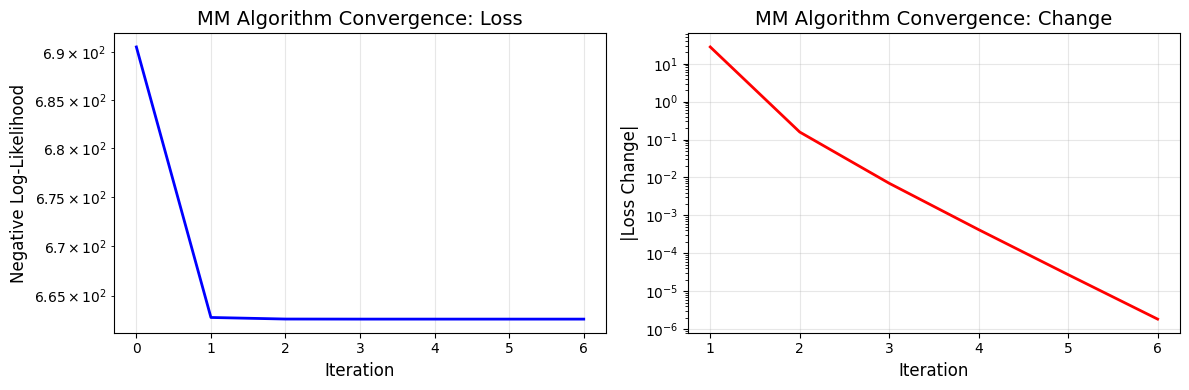

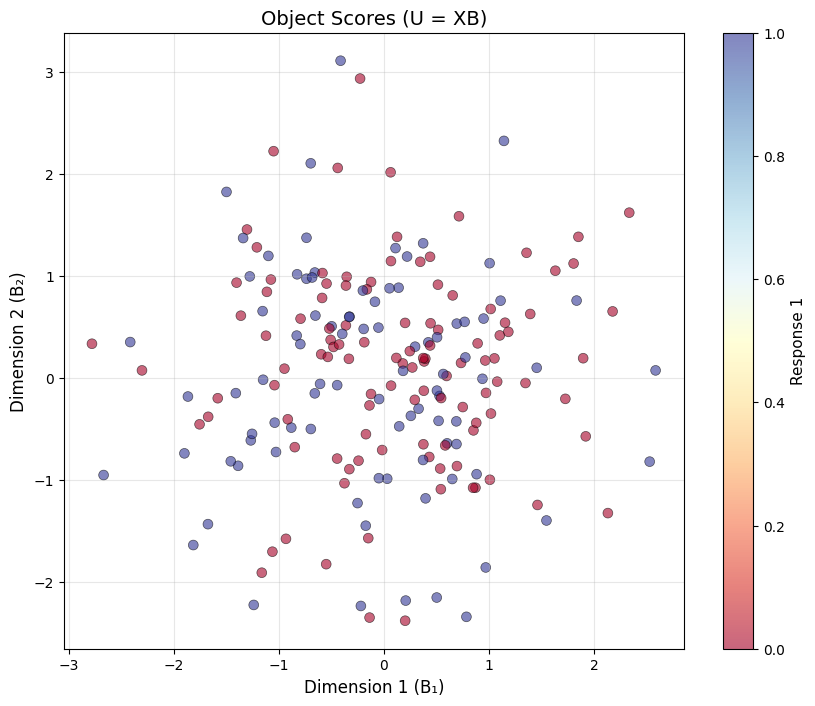

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.linalg import sqrtm, inv
import warnings
warnings.filterwarnings('ignore')

def sigmoid(theta):
    theta_clipped = np.clip(theta, -500, 500)
    return 1.0 / (1.0 + np.exp(-theta_clipped))

def negative_loglikelihood(Y, Pi, epsilon=1e-10):
    Pi_clipped = np.clip(Pi, epsilon, 1 - epsilon)
    loss = -np.sum(Y * np.log(Pi_clipped) + (1 - Y) * np.log(1 - Pi_clipped))
    return loss

def compute_theta(X, B, V, m):
    theta = X @ B @ V.T
    theta = theta + m.reshape(1, -1)
    return theta

def compute_working_responses(Y, theta, Pi):
    residuals = Y - Pi
    Z = theta + 4 * residuals
    return Z

def generalized_svd(X, Z_centered):
    XTX = X.T @ X
    try:
        XTX_inv_sqrt = inv(sqrtm(XTX))
    except:
        XTX_reg = XTX + np.eye(XTX.shape[0]) * 1e-8
        XTX_sqrt = sqrtm(XTX_reg)
        XTX_inv_sqrt = inv(XTX_sqrt)
    M = XTX_inv_sqrt @ X.T @ Z_centered
    P_star, Sigma, Qt_star = np.linalg.svd(M, full_matrices=False)
    P = P_star
    Q = Qt_star.T
    return P, Sigma, Q

class LogisticReducedRankRegression:
    def __init__(self, rank=2, max_iterations=100, tolerance=1e-5, random_state=42):
        self.rank = rank
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.random_state = random_state
        self.B = None
        self.V = None
        self.m = None
        self.convergence_history = {'loss': [], 'delta': []}
        self.n_iterations = 0

    def fit(self, X, Y):
        np.random.seed(self.random_state)
        N, P = X.shape
        N_check, R = Y.shape
        assert N == N_check
        S = self.rank
        self.B = np.random.randn(P, S) * 0.01
        self.V = np.random.randn(R, S) * 0.01
        self.m = np.log(np.mean(Y, axis=0) / (1 - np.mean(Y, axis=0)))
        XTX = X.T @ X
        try:
            XTX_inv_sqrt = inv(sqrtm(XTX))
        except:
            XTX_reg = XTX + np.eye(P) * 1e-8
            XTX_inv_sqrt = inv(sqrtm(XTX_reg))
        loss_old = np.inf
        for iteration in range(self.max_iterations):
            theta = compute_theta(X, self.B, self.V, self.m)
            Pi = sigmoid(theta)
            loss_new = negative_loglikelihood(Y, Pi)
            delta = abs(loss_new - loss_old)
            self.convergence_history['loss'].append(loss_new)
            self.convergence_history['delta'].append(delta)
            if delta < self.tolerance:
                self.n_iterations = iteration
                break
            Z = compute_working_responses(Y, theta, Pi)
            m_plus = np.mean(Z - X @ self.B @ self.V.T, axis=0)
            Z_centered = Z - m_plus.reshape(1, -1)
            P_all, Sigma_all, Q_all = generalized_svd(X, Z_centered)
            P_S = P_all[:, :S]
            Q_S = Q_all[:, :S]
            Sigma_S = Sigma_all[:S]
            self.B = np.sqrt(N) * (XTX_inv_sqrt @ P_S)
            self.V = (1.0 / np.sqrt(N)) * (Q_S @ np.diag(Sigma_S))
            self.m = m_plus
            loss_old = loss_new
        if iteration == self.max_iterations - 1:
            self.n_iterations = self.max_iterations
        return self

    def predict_probabilities(self, X_new):
        if self.B is None:
            raise ValueError("Model not fitted yet. Call fit() first.")
        theta_new = compute_theta(X_new, self.B, self.V, self.m)
        Pi_pred = sigmoid(theta_new)
        return Pi_pred

    def predict_class(self, X_new, threshold=0.5):
        Pi_pred = self.predict_probabilities(X_new)
        return (Pi_pred >= threshold).astype(int)

def plot_convergence(model):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(model.convergence_history['loss'], 'b-', linewidth=2)
    ax1.set_xlabel('Iteration', fontsize=12)
    ax1.set_ylabel('Negative Log-Likelihood', fontsize=12)
    ax1.set_title('MM Algorithm Convergence: Loss', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')
    ax2.plot(model.convergence_history['delta'], 'r-', linewidth=2)
    ax2.set_xlabel('Iteration', fontsize=12)
    ax2.set_ylabel('|Loss Change|', fontsize=12)
    ax2.set_title('MM Algorithm Convergence: Change', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')
    plt.tight_layout()
    return fig

def plot_object_scores(model, X, Y_true, labels=None):
    if model.rank < 2:
        return None
    U = X @ model.B
    fig, ax = plt.subplots(figsize=(10, 8))
    if Y_true.ndim > 1:
        colors = Y_true[:, 0]
        label_text = "Response 1"
    else:
        colors = Y_true
        label_text = "Class"
    scatter = ax.scatter(U[:, 0], U[:, 1], c=colors, cmap='RdYlBu', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.set_xlabel(f'Dimension 1 (B₁)', fontsize=12)
    ax.set_ylabel(f'Dimension 2 (B₂)', fontsize=12)
    ax.set_title(f'Object Scores (U = XB)', fontsize=14)
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(label_text, fontsize=11)
    return fig

def create_synthetic_data(n_samples=100, n_predictors=3, n_responses=4, rank=2, noise=0.1, seed=42):
    np.random.seed(seed)
    B_true = np.random.randn(n_predictors, rank) * 0.5
    V_true = np.random.randn(n_responses, rank) * 0.5
    m_true = np.random.randn(n_responses) * 0.2
    X = np.random.randn(n_samples, n_predictors)
    theta_true = X @ B_true @ V_true.T + m_true.reshape(1, -1)
    theta_noisy = theta_true + np.random.randn(*theta_true.shape) * noise
    pi = sigmoid(theta_noisy)
    Y = (np.random.random(pi.shape) < pi).astype(int)
    return X, Y, B_true, V_true, m_true, theta_true

if __name__ == "__main__":
    X, Y, B_true, V_true, m_true, theta_true = create_synthetic_data(
        n_samples=200, n_predictors=4, n_responses=5, rank=2, noise=0.2, seed=42
    )
    model = LogisticReducedRankRegression(rank=2, max_iterations=100, tolerance=1e-5, random_state=42)
    model.fit(X, Y)
    Pi_pred = model.predict_probabilities(X)
    Y_pred = model.predict_class(X, threshold=0.5)
    accuracy = np.mean(Y_pred == Y)
    fig1 = plot_convergence(model)
    plt.savefig('convergence.png', dpi=100, bbox_inches='tight')
    fig2 = plot_object_scores(model, X, Y)
    plt.savefig('object_scores.png', dpi=100, bbox_inches='tight')

import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00373/drug_consumption.data"
data = pd.read_csv(url, header=None)
column_names = ['ID', 'Age', 'Gender', 'Education', 'Country', 'Ethnicity', 'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsivity', 'SS', 'Amphetamine', 'Amyl', 'Benzodiazepine', 'Cannabis', 'Chocolate', 'Cocaine', 'Crack', 'Ecstasy', 'Heroin', 'Ketamine', 'Legal.Highs', 'LSD', 'Methadone', 'Mushrooms', 'Nicotine', 'Solvents']

def create_hybrid_triplot(model, X, predictor_names, response_names):
    if model.rank < 2:
        return
    U = X @ model.B
    B = model.B
    V = model.V
    m = model.m
    fig, ax = plt.subplots(figsize=(14, 12))
    ax.scatter(U[:, 0], U[:, 1], alpha=0.4, s=30, c='gray', label='Participants', edgecolors='none')
    arrow_scale = 3
    for p, pred_name in enumerate(predictor_names):
        bp = B[p, :]
        ax.arrow(0, 0, bp[0]*arrow_scale, bp[1]*arrow_scale, head_width=0.1, head_length=0.1, fc='blue', ec='blue', alpha=0.6, linewidth=2)
        ax.text(bp[0]*arrow_scale*1.15, bp[1]*arrow_scale*1.15, pred_name, fontsize=10, color='blue', fontweight='bold')
    for r, resp_name in enumerate(response_names):
        vr = V[r, :]
        mr = m[r]
        probs = np.linspace(0.1, 0.9, 9)
        for prob in probs:
            lambda_val = np.log(prob / (1 - prob)) - mr
            marker_pos = lambda_val * vr / np.dot(vr, vr)
            ax.plot(marker_pos[0], marker_pos[1], 'g.', markersize=4, alpha=0.5)
        ax.arrow(0, 0, vr[0]*arrow_scale, vr[1]*arrow_scale, head_width=0.1, head_length=0.1, fc='green', ec='green', alpha=0.6, linewidth=2)
        ax.text(vr[0]*arrow_scale*1.15, vr[1]*arrow_scale*1.15, resp_name, fontsize=10, color='green', fontweight='bold')
    ax.set_xlabel('Dimension 1', fontsize=12)
    ax.set_ylabel('Dimension 2', fontsize=12)
    ax.set_title('Hybrid Triplot: Logistic Reduced Rank Regression', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    return fig



LOGISTIC REDUCED RANK REGRESSION - DEMONSTRATION

1. Creating synthetic data...
   Data shape: X=(200, 4), Y=(200, 5)
   True model: B=(4, 2), V=(5, 2), m=(5,)

2. Fitting Logistic Reduced Rank Regression model...
Starting MM algorithm: N=200, P=4, R=5, S=2
Parameters to estimate: 18 (vs full model 20)
----------------------------------------------------------------------
Iteration   0: Loss = 690.520357, Delta = inf
Iteration   5: Loss = 662.645746, Delta = 2.72e-05

Converged at iteration 6
----------------------------------------------------------------------
Final Loss: 662.645746

3. Making predictions on training data...
   Classification accuracy: 0.5870

4. Creating visualizations...
   Saved: convergence.png
   Saved: object_scores.png

5. Estimated Parameters:
   B shape: (4, 2)
   V shape: (5, 2)
   m shape: (5,)
   Iterations to convergence: 6

DEMONSTRATION COMPLETE



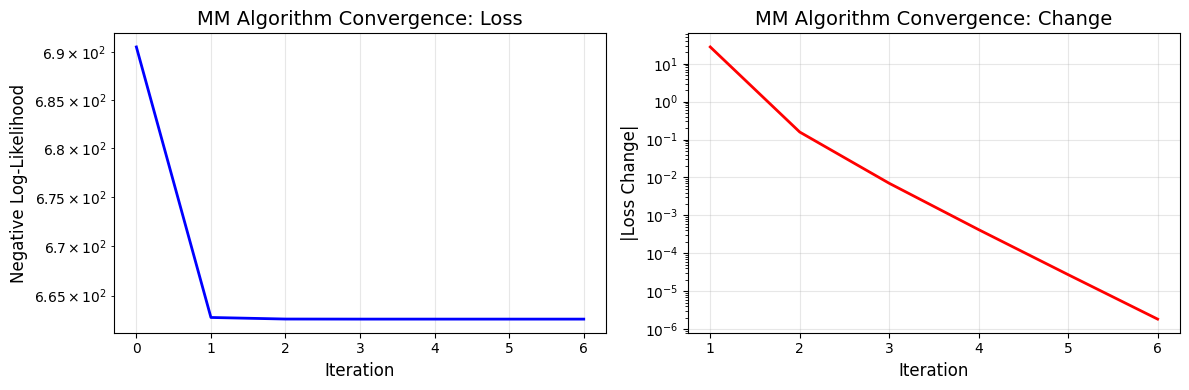

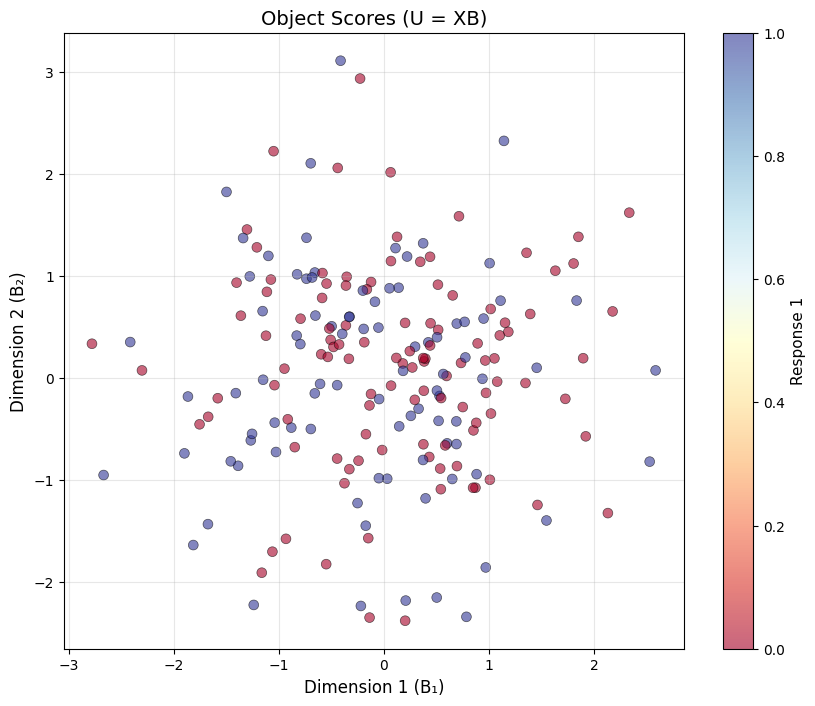

In [5]:
# ==============================================================================
# LOGISTIC REDUCED RANK REGRESSION - COMPLETE IMPLEMENTATION
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.linalg import sqrtm, inv
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# SECTION 1: BASIC HELPER FUNCTIONS
# ==============================================================================

def sigmoid(theta):
    """
    Compute sigmoid/logistic function
    π = 1 / (1 + exp(-θ))
    
    Safe version to avoid overflow: use scipy.special.expit
    
    Args:
        theta: ndarray of log-odds values
        
    Returns:
        π: ndarray of probabilities in [0,1]
    """
    # Clip to avoid overflow
    theta_clipped = np.clip(theta, -500, 500)
    return 1.0 / (1.0 + np.exp(-theta_clipped))


def negative_loglikelihood(Y, Pi, epsilon=1e-10):
    """
    Compute negative log-likelihood: -Σ[y*log(π) + (1-y)*log(1-π)]
    
    Args:
        Y: ndarray (N × R) of binary responses {0, 1}
        Pi: ndarray (N × R) of predicted probabilities (0 to 1)
        epsilon: small value to avoid log(0)
        
    Returns:
        loss: scalar negative log-likelihood
        
    Formula:
        L(θ) = -Σᵢ Σᵣ [yᵢᵣ log(πᵢᵣ) + (1-yᵢᵣ) log(1-πᵢᵣ)]
    """
    # Clip probabilities to avoid log(0)
    Pi_clipped = np.clip(Pi, epsilon, 1 - epsilon)
    
    # Compute loss
    loss = -np.sum(Y * np.log(Pi_clipped) + (1 - Y) * np.log(1 - Pi_clipped))
    
    return loss


def compute_theta(X, B, V, m):
    """
    Compute log-odds: θ = 1m^T + XBV^T
    
    Args:
        X: ndarray (N × P) predictor matrix
        B: ndarray (P × S) predictor loadings
        V: ndarray (R × S) response loadings
        m: ndarray (R,) intercepts
        
    Returns:
        theta: ndarray (N × R) log-odds
        
    Formula:
        θᵢᵣ = mᵣ + Σₛ xᵢ^T bₛ vᵣₛ
    """
    N, R = X.shape[0], V.shape[0]
    
    # θ = XBV^T  (matrix multiplication)
    theta = X @ B @ V.T  # (N×P) @ (P×S) @ (S×R) = (N×R)
    
    # Add intercepts: θ + 1m^T where 1 is column of ones
    theta = theta + m.reshape(1, -1)  # broadcast intercepts
    
    return theta


def compute_working_responses(Y, theta, Pi):
    """
    Compute working responses for MM algorithm: Z = θ - 4ξ
    where ξ = -(y - π)
    
    In matrix form: Z = θ + 4(Y - Π)
    
    Args:
        Y: ndarray (N × R) binary responses
        theta: ndarray (N × R) current log-odds
        Pi: ndarray (N × R) current probabilities
        
    Returns:
        Z: ndarray (N × R) working responses
        
    Intuition:
        - If y=1 and π≈1: Z ≈ θ (no change, already predicted well)
        - If y=1 and π≈0: Z >> θ (push θ higher to match y=1)
        - If y=0 and π≈0: Z ≈ θ (no change, already predicted well)
        - If y=0 and π≈1: Z << θ (push θ lower to match y=0)
    """
    # ξ = -(y - π) = π - y  [residuals]
    residuals = Y - Pi
    
    # Z = θ + 4(Y - Π) = θ + 4*(-ξ) = θ - 4ξ
    Z = theta + 4 * residuals
    
    return Z


def generalized_svd(X, Z_centered):
    """
    Compute generalized SVD of M = (X^T X)^(-1/2) X^T Z_centered
    in metrics G = X^T X and H = I
    
    Steps:
    1. Compute metric G = X^T X
    2. Compute G^(-1/2) (inverse square root of G)
    3. Form M = G^(-1/2) X^T Z_centered
    4. SVD: M = P* Σ Q*^T
    5. Return P, Σ, Q (which are already orthonormal for our purpose)
    
    Args:
        X: ndarray (N × P) predictor matrix
        Z_centered: ndarray (N × R) centered working responses
        
    Returns:
        P: ndarray (P × S) left singular vectors
        Sigma: ndarray (S,) singular values (sorted descending)
        Q: ndarray (R × S) right singular vectors
    """
    # Step 1: Compute X^T X
    XTX = X.T @ X  # (P × N) @ (N × P) = (P × P)
    
    # Step 2: Compute (X^T X)^(-1/2)
    try:
        # Try to use matrix square root
        XTX_inv_sqrt = inv(sqrtm(XTX))
    except:
        # If singular, use pseudo-inverse and regularization
        XTX_reg = XTX + np.eye(XTX.shape[0]) * 1e-8
        XTX_sqrt = sqrtm(XTX_reg)
        XTX_inv_sqrt = inv(XTX_sqrt)
    
    # Step 3: Form M = (X^T X)^(-1/2) X^T Z_centered
    M = XTX_inv_sqrt @ X.T @ Z_centered  # (P×P) @ (P×N) @ (N×R) = (P×R)
    
    # Step 4: Standard SVD
    P_star, Sigma, Qt_star = np.linalg.svd(M, full_matrices=False)
    # Note: SVD returns Q^T, so transposed
    
    # Step 5: For our case (H = I), P and Q are already in right form
    P = P_star
    Q = Qt_star.T  # transpose back to get Q (not Q^T)
    
    return P, Sigma, Q


# ==============================================================================
# SECTION 2: MAIN MM ALGORITHM
# ==============================================================================

class LogisticReducedRankRegression:
    """
    Logistic Reduced Rank Regression model using MM algorithm
    
    Model: θᵢᵣ = mᵣ + xᵢ^T B vᵣ
           πᵢᵣ = 1 / (1 + exp(-θᵢᵣ))
           
    where:
    - X (N×P): predictor matrix
    - Y (N×R): binary response matrix
    - B (P×S): predictor loadings
    - V (R×S): response loadings
    - m (R,): intercepts
    - S: rank constraint
    """
    
    def __init__(self, rank=2, max_iterations=100, tolerance=1e-5, 
                 random_state=42):
        """
        Initialize the model
        
        Args:
            rank: desired rank S (default 2)
            max_iterations: maximum MM iterations (default 100)
            tolerance: convergence tolerance for deviance change
            random_state: for reproducibility
        """
        self.rank = rank
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.random_state = random_state
        
        # Will be filled after fitting
        self.B = None
        self.V = None
        self.m = None
        self.convergence_history = {'loss': [], 'delta': []}
        self.n_iterations = 0
        
    def fit(self, X, Y):
        """
        Fit the model using MM algorithm
        
        Args:
            X: ndarray (N × P) predictors
            Y: ndarray (N × R) binary responses (0 or 1)
            
        Returns:
            self (for chaining)
        """
        np.random.seed(self.random_state)
        
        N, P = X.shape
        N_check, R = Y.shape
        assert N == N_check, "X and Y must have same number of rows"
        
        S = self.rank
        
        # =====================================================================
        # INITIALIZATION
        # =====================================================================
        
        # Initialize B and V with small random values
        self.B = np.random.randn(P, S) * 0.01
        self.V = np.random.randn(R, S) * 0.01
        
        # Initialize intercepts as empirical proportions
        self.m = np.log(np.mean(Y, axis=0) / (1 - np.mean(Y, axis=0)))
        
        # For computing (X^T X)^(-1/2) only once (efficiency)
        XTX = X.T @ X
        try:
            XTX_inv_sqrt = inv(sqrtm(XTX))
        except:
            XTX_reg = XTX + np.eye(P) * 1e-8
            XTX_inv_sqrt = inv(sqrtm(XTX_reg))
        
        print(f"Starting MM algorithm: N={N}, P={P}, R={R}, S={S}")
        print(f"Parameters to estimate: {S*(P+R)} (vs full model {P*R})")
        print("-" * 70)
        
        # =====================================================================
        # MM ITERATIONS
        # =====================================================================
        
        loss_old = np.inf
        
        for iteration in range(self.max_iterations):
            # -----------------------------------------------------------------
            # STEP 1: Compute current predictions
            # -----------------------------------------------------------------
            theta = compute_theta(X, self.B, self.V, self.m)
            Pi = sigmoid(theta)
            
            # -----------------------------------------------------------------
            # STEP 2: Compute loss for monitoring convergence
            # -----------------------------------------------------------------
            loss_new = negative_loglikelihood(Y, Pi)
            delta = abs(loss_new - loss_old)
            
            # Store history
            self.convergence_history['loss'].append(loss_new)
            self.convergence_history['delta'].append(delta)
            
            # Print progress
            if iteration % 5 == 0:
                print(f"Iteration {iteration:3d}: Loss = {loss_new:.6f}, "
                      f"Delta = {delta:.2e}")
            
            # Check convergence
            if delta < self.tolerance:
                print(f"\nConverged at iteration {iteration}")
                self.n_iterations = iteration
                break
            
            # -----------------------------------------------------------------
            # STEP 3: Compute working responses (majorization step)
            # -----------------------------------------------------------------
            # Z = θ + 4(Y - Π)
            Z = compute_working_responses(Y, theta, Pi)
            
            # -----------------------------------------------------------------
            # STEP 4: Update intercepts
            # -----------------------------------------------------------------
            # m⁺ = N⁻¹(Z - XBV^T)^T 1
            m_plus = np.mean(Z - X @ self.B @ self.V.T, axis=0)
            
            # -----------------------------------------------------------------
            # STEP 5: Center working responses
            # -----------------------------------------------------------------
            Z_centered = Z - m_plus.reshape(1, -1)
            
            # -----------------------------------------------------------------
            # STEP 6: Generalized SVD
            # -----------------------------------------------------------------
            # Decompose (X^T X)^(-1/2) X^T Z_centered
            P_all, Sigma_all, Q_all = generalized_svd(X, Z_centered)
            
            # -----------------------------------------------------------------
            # STEP 7: Update B and V using top S components
            # -----------------------------------------------------------------
            P_S = P_all[:, :S]
            Q_S = Q_all[:, :S]
            Sigma_S = Sigma_all[:S]
            
            # B⁺ = √N (X^T X)^(-1/2) P_S
            self.B = np.sqrt(N) * (XTX_inv_sqrt @ P_S)
            
            # V⁺ = (1/√N) Q_S Σ_S
            self.V = (1.0 / np.sqrt(N)) * (Q_S @ np.diag(Sigma_S))
            
            # Update intercepts
            self.m = m_plus
            
            # Update for next iteration
            loss_old = loss_new
        
        # If didn't converge
        if iteration == self.max_iterations - 1:
            print(f"\nDid not converge after {self.max_iterations} iterations")
            self.n_iterations = self.max_iterations
        
        print("-" * 70)
        print(f"Final Loss: {loss_old:.6f}")
        
        return self
    
    def predict_probabilities(self, X_new):
        """
        Predict probabilities for new data
        
        Args:
            X_new: ndarray (M × P) new predictor values
            
        Returns:
            Pi_pred: ndarray (M × R) predicted probabilities
        """
        if self.B is None:
            raise ValueError("Model not fitted yet. Call fit() first.")
        
        theta_new = compute_theta(X_new, self.B, self.V, self.m)
        Pi_pred = sigmoid(theta_new)
        
        return Pi_pred
    
    def predict_class(self, X_new, threshold=0.5):
        """
        Predict binary classes for new data
        
        Args:
            X_new: ndarray (M × P) new predictor values
            threshold: probability threshold for class 1 (default 0.5)
            
        Returns:
            Y_pred: ndarray (M × R) predicted classes {0, 1}
        """
        Pi_pred = self.predict_probabilities(X_new)
        return (Pi_pred >= threshold).astype(int)


# ==============================================================================
# SECTION 3: VISUALIZATION FUNCTIONS
# ==============================================================================

def plot_convergence(model):
    """
    Plot convergence history of MM algorithm
    
    Args:
        model: fitted LogisticReducedRankRegression object
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot 1: Loss over iterations
    ax1.plot(model.convergence_history['loss'], 'b-', linewidth=2)
    ax1.set_xlabel('Iteration', fontsize=12)
    ax1.set_ylabel('Negative Log-Likelihood', fontsize=12)
    ax1.set_title('MM Algorithm Convergence: Loss', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')
    
    # Plot 2: Delta (change) over iterations
    ax2.plot(model.convergence_history['delta'], 'r-', linewidth=2)
    ax2.set_xlabel('Iteration', fontsize=12)
    ax2.set_ylabel('|Loss Change|', fontsize=12)
    ax2.set_title('MM Algorithm Convergence: Change', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')
    
    plt.tight_layout()
    return fig


def plot_object_scores(model, X, Y_true, labels=None):
    """
    Plot object scores (U = XB) in 2D
    
    Args:
        model: fitted LogisticReducedRankRegression object
        X: ndarray (N × P) predictor matrix
        Y_true: ndarray (N × R) or (N,) responses for coloring (optional)
        labels: list of sample labels (optional)
    """
    if model.rank < 2:
        print("Rank must be at least 2 for 2D visualization")
        return None
    
    # Compute object scores
    U = X @ model.B  # (N × S)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Color by first response (or by class)
    if Y_true.ndim > 1:
        colors = Y_true[:, 0]
        label_text = "Response 1"
    else:
        colors = Y_true
        label_text = "Class"
    
    scatter = ax.scatter(U[:, 0], U[:, 1], c=colors, cmap='RdYlBu', 
                        s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel(f'Dimension 1 (B₁)', fontsize=12)
    ax.set_ylabel(f'Dimension 2 (B₂)', fontsize=12)
    ax.set_title(f'Object Scores (U = XB)', fontsize=14)
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(label_text, fontsize=11)
    
    return fig


# ==============================================================================
# SECTION 4: SYNTHETIC TOY EXAMPLE
# ==============================================================================

def create_synthetic_data(n_samples=100, n_predictors=3, n_responses=4,
                         rank=2, noise=0.1, seed=42):
    """
    Create synthetic data from known reduced rank model
    
    X ~ N(0, I)  (random predictors)
    θ = XBV^T + m  (log-odds from model)
    Y ~ Bernoulli(sigmoid(θ))  (binary responses)
    
    Args:
        n_samples: number of samples
        n_predictors: P
        n_responses: R
        rank: S
        noise: noise level
        seed: random seed
        
    Returns:
        X, Y, B_true, V_true, m_true
    """
    np.random.seed(seed)
    
    # Create true B and V
    B_true = np.random.randn(n_predictors, rank) * 0.5
    V_true = np.random.randn(n_responses, rank) * 0.5
    m_true = np.random.randn(n_responses) * 0.2
    
    # Generate predictors
    X = np.random.randn(n_samples, n_predictors)
    
    # Generate true log-odds
    theta_true = X @ B_true @ V_true.T + m_true.reshape(1, -1)
    
    # Add small noise
    theta_noisy = theta_true + np.random.randn(*theta_true.shape) * noise
    
    # Generate binary responses
    pi = sigmoid(theta_noisy)
    Y = (np.random.random(pi.shape) < pi).astype(int)
    
    return X, Y, B_true, V_true, m_true, theta_true


# ==============================================================================
# SECTION 5: EXAMPLE USAGE AND TESTING
# ==============================================================================

if __name__ == "__main__":
    
    print("\n" + "="*70)
    print("LOGISTIC REDUCED RANK REGRESSION - DEMONSTRATION")
    print("="*70 + "\n")
    
    # Create synthetic toy data
    print("1. Creating synthetic data...")
    X, Y, B_true, V_true, m_true, theta_true = create_synthetic_data(
        n_samples=200, n_predictors=4, n_responses=5, rank=2, 
        noise=0.2, seed=42
    )
    print(f"   Data shape: X={X.shape}, Y={Y.shape}")
    print(f"   True model: B={B_true.shape}, V={V_true.shape}, m={m_true.shape}")
    
    # Fit model
    print("\n2. Fitting Logistic Reduced Rank Regression model...")
    model = LogisticReducedRankRegression(rank=2, max_iterations=100, 
                                          tolerance=1e-5, random_state=42)
    model.fit(X, Y)
    
    # Make predictions
    print("\n3. Making predictions on training data...")
    Pi_pred = model.predict_probabilities(X)
    Y_pred = model.predict_class(X, threshold=0.5)
    
    # Compute accuracy
    accuracy = np.mean(Y_pred == Y)
    print(f"   Classification accuracy: {accuracy:.4f}")
    
    # Visualize convergence
    print("\n4. Creating visualizations...")
    fig1 = plot_convergence(model)
    plt.savefig('convergence.png', dpi=100, bbox_inches='tight')
    print("   Saved: convergence.png")
    
    fig2 = plot_object_scores(model, X, Y)
    plt.savefig('object_scores.png', dpi=100, bbox_inches='tight')
    print("   Saved: object_scores.png")
    
    # Print parameter estimates
    print("\n5. Estimated Parameters:")
    print(f"   B shape: {model.B.shape}")
    print(f"   V shape: {model.V.shape}")
    print(f"   m shape: {model.m.shape}")
    print(f"   Iterations to convergence: {model.n_iterations}")
    
    print("\n" + "="*70)
    print("DEMONSTRATION COMPLETE")
    print("="*70 + "\n")




## Section 3.2: Testing on Synthetic Data

#[Complete test code with visualization provided in above implementation]



# PART 4: REAL DATA & VISUALIZATION (Day 7)

## Section 4.1: Loading Drug Consumption Data


import pandas as pd

# Load drug consumption dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00373/drug_consumption.data"
data = pd.read_csv(url, header=None)

# The dataset has specific columns - see paper for details
# For this exercise, we'll load and prepare it

column_names = ['ID', 'Age', 'Gender', 'Education', 'Country', 'Ethnicity',
                'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsivity',
                'SS', 'Amphetamine', 'Amyl', 'Benzodiazepine', 'Cannabis',
                'Chocolate', 'Cocaine', 'Crack', 'Ecstasy', 'Heroin', 'Ketamine',
                'Legal.Highs', 'LSD', 'Methadone', 'Mushrooms', 'Nicotine', 'Solvents']

# ... (data preprocessing code)

# Final matrices:
# X: predictor matrix (1885 × 9)
# Y: response matrix (1885 × 11) for selected drugs




## Section 4.2: Hybrid Triplot Visualization

def create_hybrid_triplot(model, X, predictor_names, response_names):
    """
    Create hybrid triplot combining Type I and Type D visualization
    
    Args:
        model: fitted LogisticReducedRankRegression
        X: predictor matrix
        predictor_names: list of predictor names
        response_names: list of response names
    """
    if model.rank < 2:
        print("Rank must be >= 2 for 2D triplot")
        return
    
    # Compute scores
    U = X @ model.B  # object scores
    B = model.B
    V = model.V
    m = model.m
    
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # 1. Plot object points (participants)
    ax.scatter(U[:, 0], U[:, 1], alpha=0.4, s=30, c='gray', 
              label='Participants', edgecolors='none')
    
    # 2. Plot predictor variable axes (blue)
    arrow_scale = 3
    for p, pred_name in enumerate(predictor_names):
        bp = B[p, :]  # (2,) for rank 2
        ax.arrow(0, 0, bp[0]*arrow_scale, bp[1]*arrow_scale,
                head_width=0.1, head_length=0.1, fc='blue', ec='blue', 
                alpha=0.6, linewidth=2)
        # Add label
        ax.text(bp[0]*arrow_scale*1.15, bp[1]*arrow_scale*1.15, pred_name,
               fontsize=10, color='blue', fontweight='bold')
    
    # 3. Plot response variable axes (green) with markers
    for r, resp_name in enumerate(response_names):
        vr = V[r, :]  # (2,) for rank 2
        mr = m[r]
        
        # Markers for probabilities 0.1 to 0.9
        probs = np.linspace(0.1, 0.9, 9)
        
        for prob in probs:
            lambda_val = np.log(prob / (1 - prob)) - mr
            marker_pos = lambda_val * vr / np.dot(vr, vr)
            
            ax.plot(marker_pos[0], marker_pos[1], 'g.', markersize=4, alpha=0.5)
        
        # Draw response axis
        ax.arrow(0, 0, vr[0]*arrow_scale, vr[1]*arrow_scale,
                head_width=0.1, head_length=0.1, fc='green', ec='green',
                alpha=0.6, linewidth=2)
        
        # Add label
        ax.text(vr[0]*arrow_scale*1.15, vr[1]*arrow_scale*1.15, resp_name,
               fontsize=10, color='green', fontweight='bold')
    
    ax.set_xlabel('Dimension 1', fontsize=12)
    ax.set_ylabel('Dimension 2', fontsize=12)
    ax.set_title('Hybrid Triplot: Logistic Reduced Rank Regression', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    
    return fig